In [1]:
import pandas as pd
import numpy as np

# IBM  Telco Customer Churn online dataset load
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# check data is successfully loaded or not
print("data is loaded successfully")
print("ડેટાનું કદ (Rows, Columns):", df.shape)

# record of first 5 person
df.head()

data is loaded successfully
ડેટાનું કદ (Rows, Columns): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
from sklearn.preprocessing import LabelEncoder

# 1. Drop Unnecessary Columns
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# 2. Fix 'TotalCharges' without warning
if df['TotalCharges'].dtype == 'object':
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Fill missing values directly without using inplace=True
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Encode Target Variable ('Churn') safely
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. One-Hot Encoding with dtype=int (Generates 0 and 1 cleanly)
df_clean = pd.get_dummies(df, drop_first=True, dtype=int)

df_clean.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


C:\Users\AI\AppData\Local\Temp\ipykernel_4048\4017366785.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
C:\Users\AI\AppData\Local\Temp\ipykernel_4048\4017366785.py:37: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn'] == 0]['MonthlyCharges'], label='No Churn (Stayed)', color='#2ecc71', shade=True)
C:\Users\AI\AppData\Local\Temp\ipykernel_4048\4017366785.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn'] == 1]['MonthlyCharges'], label='Churned', color='#e74c3c', shade=True)


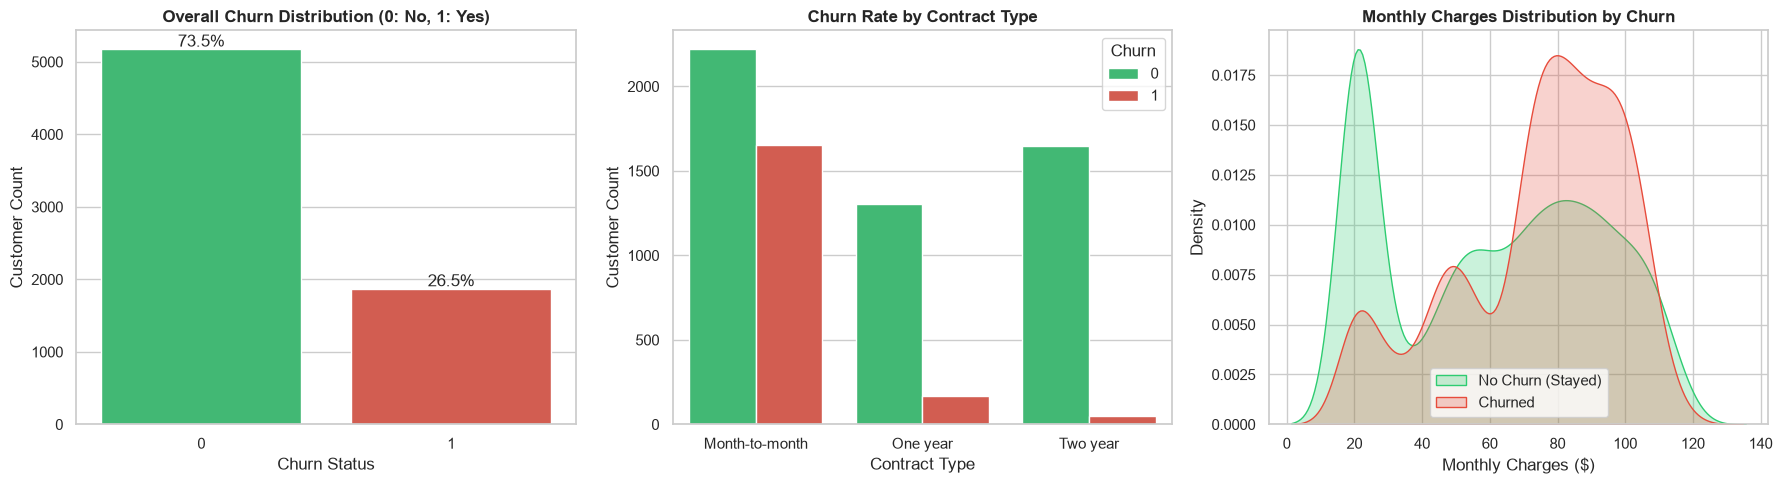

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# -------------------------------------------------------------
# Plot 1: Overall Churn Distribution
# -------------------------------------------------------------
plt.subplot(1, 3, 1)
ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Overall Churn Distribution (0: No, 1: Yes)', fontsize=12, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Customer Count')

# Add percentage labels on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# -------------------------------------------------------------
# Plot 2: Contract Type vs Churn
# -------------------------------------------------------------
plt.subplot(1, 3, 2)
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')

# -------------------------------------------------------------
# Plot 3: Monthly Charges vs Churn (KDE Plot)
# -------------------------------------------------------------
plt.subplot(1, 3, 3)
sns.kdeplot(df[df['Churn'] == 0]['MonthlyCharges'], label='No Churn (Stayed)', color='#2ecc71', shade=True)
sns.kdeplot(df[df['Churn'] == 1]['MonthlyCharges'], label='Churned', color='#e74c3c', shade=True)
plt.title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------------------------------------
# Step 4: Train-Test Split & Feature Scaling
# -------------------------------------------------------------
# Separate Features (X) and Target (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data successfully split (Train: 80%, Test: 20%) and Scaled!\n")

# -------------------------------------------------------------
# Step 5: Model 1 - Logistic Regression
# -------------------------------------------------------------
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("=" * 60)
print(f"📊 Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log) * 100:.2f}%")
print("=" * 60)

# -------------------------------------------------------------
# Step 5: Model 2 - Random Forest Classifier
# -------------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # Tree algorithms don't strictly need scaled data
y_pred_rf = rf_model.predict(X_test)

print("=" * 60)
print(f"📊 Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("=" * 60)

# Classification Report for Best Performing Model
print("\n--- Classification Report (Logistic Regression) ---")
print(classification_report(y_test, y_pred_log))

✅ Data successfully split (Train: 80%, Test: 20%) and Scaled!

📊 Logistic Regression Accuracy: 80.70%
📊 Random Forest Accuracy: 78.64%

--- Classification Report (Logistic Regression) ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



C:\Users\AI\AppData\Local\Temp\ipykernel_4048\2297032100.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_importances, y=top_10_feature_names, palette='viridis')


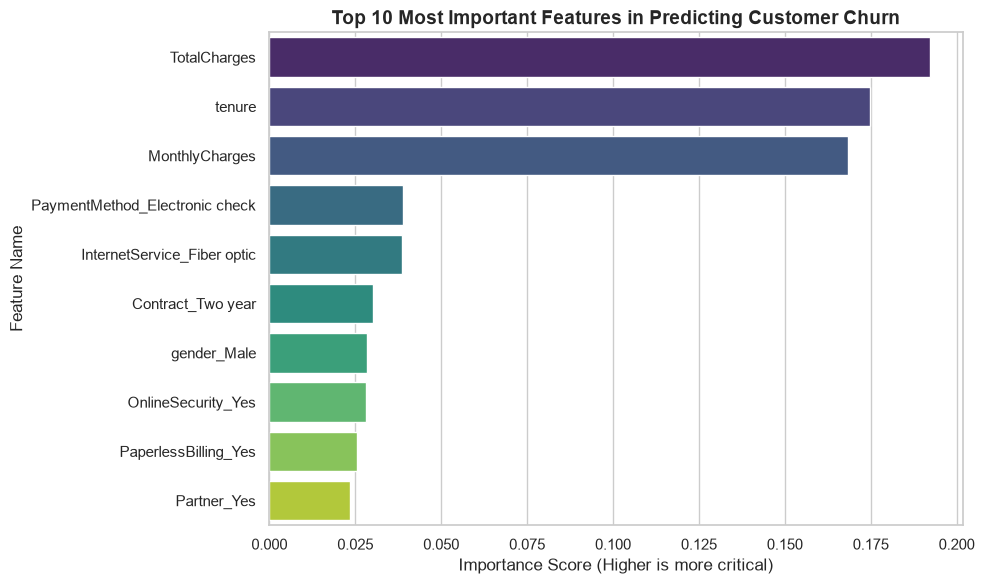

✅ Feature Importance Chart generated. Use this to identify critical business drivers!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Get feature importance scores from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# 3. Rearrange feature names so they match sorted feature importances
sorted_feature_names = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# 4. Filter only the top 10 features
top_10_feature_names = sorted_feature_names[:10]
top_10_importances = sorted_importances[:10]

# 5. Visualize the top 10 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_importances, y=top_10_feature_names, palette='viridis')
plt.title('Top 10 Most Important Features in Predicting Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Higher is more critical)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Feature Importance Chart generated. Use this to identify critical business drivers!")